In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

import env.trading_env_v2 as te2
import features.feature_engineering as fe
importlib.reload(te2)
importlib.reload(fe)

from stable_baselines3 import PPO, SAC, A2C
from stable_baselines3.common.callbacks import BaseCallback


df = pd.read_excel('../data/data.xlsx', skiprows=6, header=0)
df.columns = ['date', 'gold', 'silver', 'copper']
df = df[pd.to_datetime(df['date'], errors='coerce').notna()]
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


features_final = fe.build_features(df)


train = features_final[features_final.index <= '2023-12-31']
test = features_final[features_final.index >= '2024-01-01']
price_train = df[df.index.isin(train.index)]
price_test = df[df.index.isin(test.index)]

print(f"Train: {len(train)}days, Test: {len(test)}days")

Train: 2592days, Test: 485days


Training PPO...


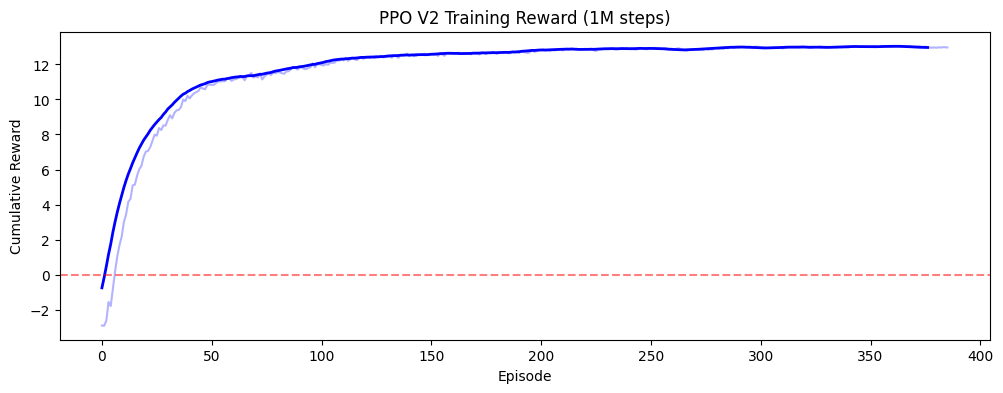

Average for the last 10 episodes: 12.9671


In [2]:
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_rewards = []
    
    def _on_step(self):
        reward = self.locals['rewards'][0]
        self.current_rewards.append(reward)
        
        if self.locals['dones'][0]:
            self.episode_rewards.append(sum(self.current_rewards))
            self.current_rewards = []
        return True

def train_agent(algorithm, env, total_timesteps=1_000_000, **kwargs):
    callback = RewardCallback()
    model = algorithm("MlpPolicy", env, verbose=0, **kwargs)
    model.learn(total_timesteps=total_timesteps, callback=callback)
    return model, callback

def plot_reward(rewards, title):
    smoothed = np.convolve(rewards, np.ones(10)/10, mode='valid')
    plt.figure(figsize=(12, 4))
    plt.plot(rewards, alpha=0.3, color='blue')
    plt.plot(smoothed, color='blue', linewidth=2)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel('Cumulative Reward')
    plt.show()

# PPO
print("Training PPO...")
train_env = te2.MetalTradingEnvV2(train, price_train)
ppo_v2, ppo_cb = train_agent(PPO, train_env, learning_rate=3e-4, n_steps=2048, batch_size=64, n_epochs=10, gamma=0.99)
plot_reward(ppo_cb.episode_rewards, "PPO V2 Training Reward (1M steps)")
print(f"Average for the last 10 episodes: {np.mean(ppo_cb.episode_rewards[-10:]):.4f}")

In [3]:
ppo_v2.save("../agents/ppo_v2_1m")
np.save("../agents/ppo_v2_rewards_1m.npy", ppo_cb.episode_rewards)
print("PPO saved!")

PPO saved!


Training SAC...


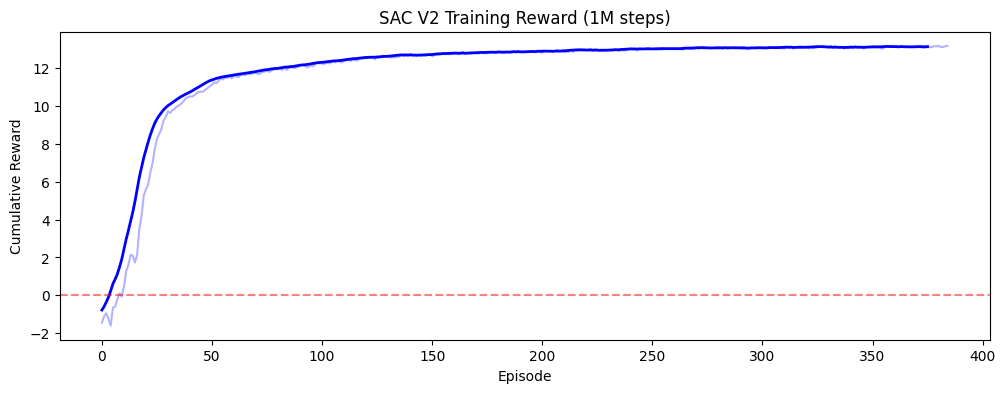

Average for the last 10 episodes: 13.1285


In [4]:
# SAC
print("Training SAC...")
train_env = te2.MetalTradingEnvV2(train, price_train)
sac_v2, sac_cb = train_agent(SAC, train_env, learning_rate=3e-4, batch_size=256, buffer_size=100_000, learning_starts=1000, gamma=0.99)
plot_reward(sac_cb.episode_rewards, "SAC V2 Training Reward (1M steps)")
print(f"Average for the last 10 episodes: {np.mean(sac_cb.episode_rewards[-10:]):.4f}")

In [5]:
sac_v2.save("../agents/sac_v2_1m")
np.save("../agents/sac_v2_rewards_1m.npy", sac_cb.episode_rewards)
print("SAC saved!")

SAC saved!


Training A2C...


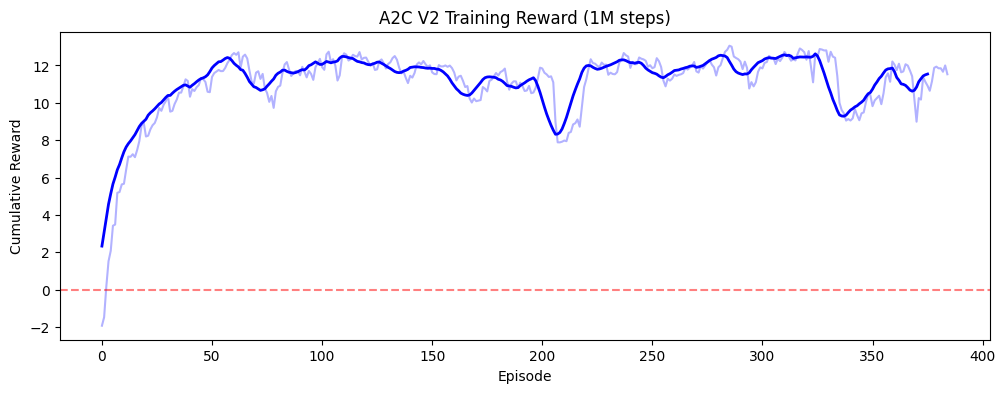

Average for the last 10 episodes: 11.5422


In [6]:
# A2C
print("Training A2C...")
train_env = te2.MetalTradingEnvV2(train, price_train)
a2c_v2, a2c_cb = train_agent(A2C, train_env, learning_rate=7e-4, n_steps=5, gamma=0.99)
plot_reward(a2c_cb.episode_rewards, "A2C V2 Training Reward (1M steps)")
print(f"Average for the last 10 episodes: {np.mean(a2c_cb.episode_rewards[-10:]):.4f}")
a2c_v2.save("../agents/a2c_v2_1m")

In [7]:
np.save("../agents/a2c_v2_rewards_1m.npy", a2c_cb.episode_rewards)
print("A2C saved!")

A2C saved!


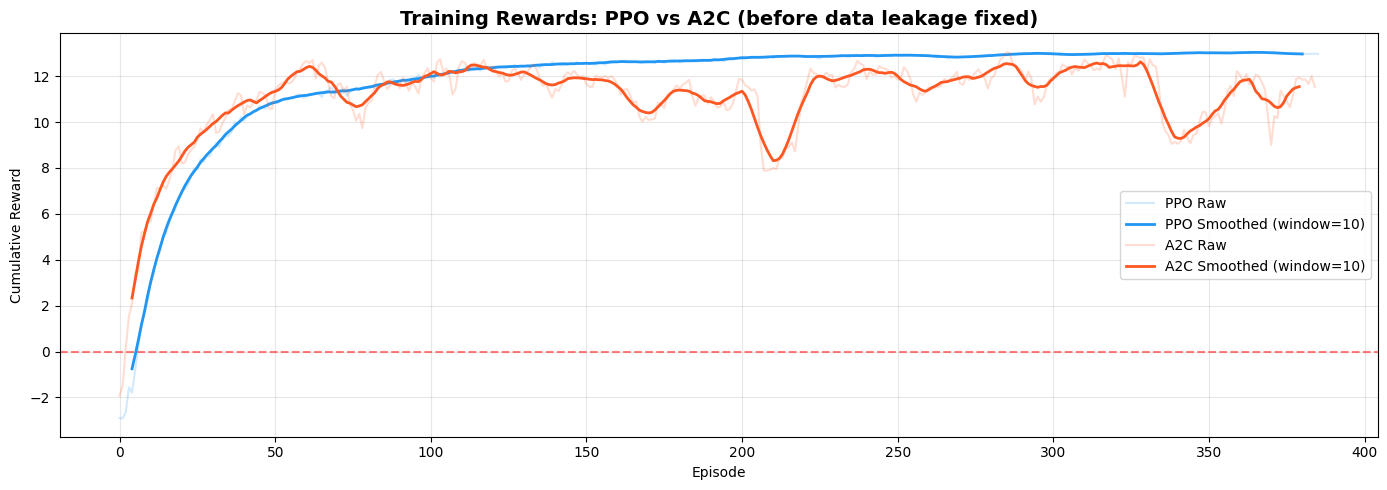

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_rewards(ppo_rewards, a2c_rewards, window=10):
    fig, ax = plt.subplots(figsize=(14, 5))
    
    agents = [
        (ppo_rewards, 'PPO', '#2196F3'),
        (a2c_rewards, 'A2C', '#FF5722'),
    ]
    
    for rewards, name, color in agents:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        offset = (len(rewards) - len(smoothed)) // 2
        
        ax.plot(rewards, alpha=0.2, color=color, label=f'{name} Raw')
        ax.plot(range(offset, offset + len(smoothed)), smoothed,
                color=color, linewidth=2, label=f'{name} Smoothed (window={window})')
    
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title('Training Rewards: PPO vs A2C (before data leakage fixed)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Cumulative Reward')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../agents/training_curves_ppo_a2c.png', dpi=150, bbox_inches='tight')
    plt.show()


ppo_rewards = np.load("../agents/ppo_v2_rewards_1m.npy")
a2c_rewards = np.load("../agents/a2c_v2_rewards_1m.npy")

plot_all_rewards(ppo_rewards, a2c_rewards, window=10)